In [1]:
import pandas as pd
import feature_selection as fs
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, recall_score, precision_score
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
import matplotlib.pyplot as plt

In [ ]:
# Add additional soph features and split dataset

soph_df = fs.load_soph_features()

soph_df['ppg_jump'] = soph_df['PTS_y2'] - soph_df['PTS_y1']
soph_df['bpm_jump'] = soph_df['BPM_y2'] - soph_df['BPM_y1']
soph_df['ts_jump'] = soph_df['TS%_y2'] - soph_df['TS%_y1']

X = soph_df.drop(columns=['Player', 'AS_After_Year_Two'])
y = soph_df['AS_After_Year_Two']

training_df = soph_df[soph_df['Rookie_Season'] <= 2018]
testing_df = soph_df[soph_df['Rookie_Season'] > 2018]

X_train = training_df.drop(columns=['Player', 'AS_After_Year_Two'])
y_train = training_df['AS_After_Year_Two']

X_test = testing_df.drop(columns=['Player', 'AS_After_Year_Two'])
y_test = testing_df['AS_After_Year_Two']

print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(1961, 48)
(1961,)
(496, 48)
(496,)


In [ ]:
# Initialize and train the model

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",6
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [ ]:
# Calibrate the model and train

calibrated_model = CalibratedClassifierCV(
    model,
    method='isotonic',
    cv=5
)

calibrated_model.fit(X_train, y_train)

,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2",RandomForestC...ndom_state=42)
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'isotonic'
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary ` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'

In [ ]:
# Feed calibrated model testing dataset 

calibrated_probs = calibrated_model.predict_proba(X_test)

calibrated_allstar_probs = calibrated_probs[:,1]

In [ ]:
# Convert projections to binary 1 and 0

calibrated_preds = (calibrated_allstar_probs >= .40).astype(int)

In [ ]:
# Calculate evaluation metrics

accuracy = accuracy_score(y_test, calibrated_preds)
recall = recall_score(y_test, calibrated_preds)
auc = roc_auc_score(y_test, calibrated_allstar_probs)
precision = precision_score(y_test, calibrated_preds)


print('Accuracy:', accuracy)
print('Recall:', recall)
print('ROC-AUC:', auc)
print('Precision:', precision)

Accuracy: 0.969758064516129
Recall: 0.6363636363636364
ROC-AUC: 0.9521001150747986
Precision: 0.6666666666666666


In [ ]:
# Configure calibration curve

prob_true, prob_pred = calibration_curve(
    y_test,
    calibrated_allstar_probs,
    n_bins=5
)

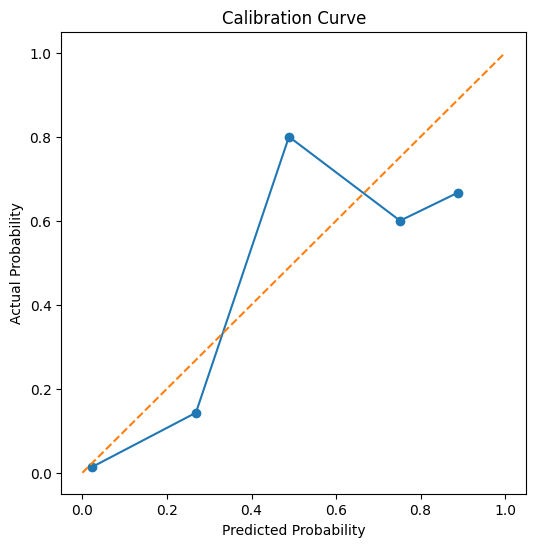

In [ ]:
# Plot calibration curve

plt.figure(figsize=(6,6))

plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("Predicted Probability")
plt.ylabel("Actual Probability")

plt.title("Calibration Curve")

plt.show()

In [ ]:
# View feature importance weights

importance_df = pd.DataFrame({'feature': X.columns, 'importance': model.feature_importances_})

importance_df = importance_df.sort_values(by='importance',ascending=False)

print(importance_df)

             feature  importance
28            PTS_y2    0.118215
36           VORP_y2    0.097137
33             WS_y2    0.093928
30            PER_y2    0.082991
29  Total_Minutes_y2    0.078564
27            TOV_y2    0.050559
22  Games_Started_y2    0.043560
35            BPM_y2    0.035856
25            STL_y2    0.028522
23            TRB_y2    0.026338
10  Total_Minutes_y1    0.023006
24            AST_y2    0.021055
8             PTS_y1    0.020661
2   Games_Started_y1    0.020480
34          WS/48_y2    0.019437
0                Age    0.018291
45          ppg_jump    0.015789
21   Games_Played_y2    0.015286
39     PTS_per100_y2    0.014638
1    Games_Played_y1    0.012372
32           USG%_y2    0.011701
17           VORP_y1    0.011262
31            TS%_y2    0.010579
14             WS_y1    0.010246
11            PER_y1    0.009487
5             STL_y1    0.008529
46          bpm_jump    0.008314
7             TOV_y1    0.008035
3             TRB_y1    0.007974
18     TRB

In [ ]:
# Load in sophomore dataset
soph_pred_df = fs.load_soph_prediction_features()

# Add additional soph features
soph_pred_df['ppg_jump'] = soph_pred_df['PTS_y2'] - soph_pred_df['PTS_y1']
soph_pred_df['bpm_jump'] = soph_pred_df['BPM_y2'] - soph_pred_df['BPM_y1']
soph_pred_df['ts_jump'] = soph_pred_df['TS%_y2'] - soph_pred_df['TS%_y1']

# Filter dataset for X and feed to model for predictions
X = soph_pred_df.drop(columns=['Player', 'AS_After_Year_Two'])

probs = calibrated_model.predict_proba(X)

soph_allstar_probs = probs[:, 1]

soph_allstar_probs


array([0.00114286, 0.04645072, 0.22621966, 0.20797349, 0.00248514,
       0.00576383, 0.01992465, 0.00248514, 0.01226468, 0.        ,
       0.06487822, 0.00134228, 0.16480169, 0.01226468, 0.01226468,
       0.00248514, 0.069337  , 0.00576383, 0.00248514, 0.79633222,
       0.00576383, 0.00248514, 0.00576383, 0.00462097, 0.00576383,
       0.        , 0.12483734, 0.        , 0.01226468, 0.03696361,
       0.00248514, 0.01349959, 0.00248514, 0.01226468, 0.00248514,
       0.06665382, 0.21914911, 0.00248514, 0.00248514, 0.00576383,
       0.00248514, 0.02930364, 0.        , 0.53007775, 0.00576383,
       0.        , 0.22491665, 0.12859674, 0.        , 0.00248514,
       0.29943129, 0.00576383, 0.00576383, 0.12156085, 0.00576383,
       0.        , 0.0960748 , 0.01912183, 0.00248514, 0.28062926,
       0.01226468, 0.00576383, 0.03234457, 0.00576383, 0.00576383,
       0.84633222, 0.00114286, 0.01262097, 0.02072119, 0.01226468,
       0.00248514, 0.07785344, 0.07317991, 0.00576383, 0.00248

In [ ]:
# Load in soph dataset and join predictions

current_soph_df = pd.read_csv('/Users/natemekonen/Desktop/Data_Projects/nba_ml_career_projections/data/final/final_soph_stats.csv', index_col=0)

current_soph_df = current_soph_df[['Player', 'Team_g_y1', 'Pos_g_y1', 'Age_a_y2', 'Images', 'logo']]

columns_to_rename = {
    'Team_g_y1' : 'Team',
    'Pos_g_y1' : 'Position',
    'Age_a_y2' : 'Age',
    'logo' : 'Team_Logo'
}

current_soph_df = current_soph_df.rename(columns=columns_to_rename)

current_soph_df['Allstar_Prob'] = soph_allstar_probs

current_soph_df = current_soph_df.sort_values(by='Allstar_Prob', ascending=False)

current_soph_df.to_csv('/Users/natemekonen/Desktop/Data_Projects/nba_ml_career_projections/data/model_output/soph_allstar_probs.csv')